## Load packages

In [1]:
import os
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

## Load dataset

In [2]:
data = pd.read_csv("data/loan_status.csv")
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Explore and clean dataset

In [3]:
df = data.copy()

In [4]:
df.shape

(614, 13)

In [5]:
# rename columns
def rename_columns(col):
    col = col.replace("_", "")
    return col

new_col = df.columns.map(rename_columns)
df.columns = new_col

df.head()

,LoanID,Gender,Married,Dependents,Education,SelfEmployed,ApplicantIncome,CoapplicantIncome,LoanAmount,LoanAmountTerm,CreditHistory,PropertyArea,LoanStatus
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   LoanID             614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   SelfEmployed       582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   LoanAmountTerm     600 non-null    float64
 10  CreditHistory      564 non-null    float64
 11  PropertyArea       614 non-null    object 
 12  LoanStatus         614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [7]:
# drop irrelevant features
df = df.drop(columns=["LoanID"])
df.head()

,Gender,Married,Dependents,Education,SelfEmployed,ApplicantIncome,CoapplicantIncome,LoanAmount,LoanAmountTerm,CreditHistory,PropertyArea,LoanStatus
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [8]:
# check unique values in dependent, it appears numerical but represented as an object type
set(df["Dependents"].values)

{'0', '1', '2', '3+', nan}

In [9]:
# check if CreditHistory is actually numerical or should be categorical
np.unique(df["CreditHistory"].values)

array([ 0.,  1., nan])

In [10]:
# Cast CreditHistory to appropriate type
df["CreditHistory"] = df["CreditHistory"].astype("category")

In [ ]:
np.unique(df["LoanAmountTerm"].values)

SyntaxError: invalid syntax (2611938908.py, line 1)

In [ ]:
# check for duplicates
df.duplicated().sum()

0

In [12]:
# missing values
df.isna().sum()

Gender               13
Married               3
Dependents           15
Education             0
SelfEmployed         32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
LoanAmountTerm       14
CreditHistory        50
PropertyArea          0
LoanStatus            0
dtype: int64

In [13]:
# numerical descriptive stats
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,LoanAmountTerm
count,614.000000,614.000000,592.000000,600.00000
mean,5403.459283,1621.245798,146.412162,342.00000
std,6109.041673,2926.248369,85.587325,65.12041
min,150.000000,0.000000,9.000000,12.00000
25%,2877.500000,0.000000,100.000000,360.00000
50%,3812.500000,1188.500000,128.000000,360.00000
75%,5795.000000,2297.250000,168.000000,360.00000
max,81000.000000,41667.000000,700.000000,480.00000


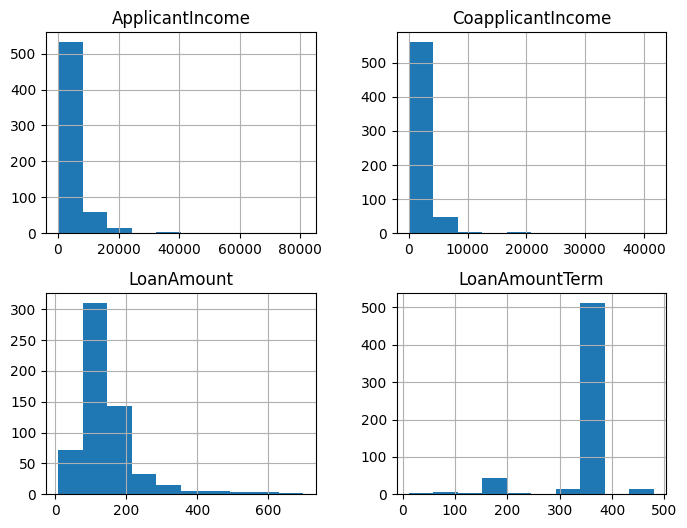

In [14]:
# numerical data distribution
axes = df.hist(bins=10, figsize=(8, 6))

In [15]:
# categorical descriptive stats
df.describe(include=["object", "category"])

,Gender,Married,Dependents,Education,SelfEmployed,CreditHistory,PropertyArea,LoanStatus
count,601,611,599,614,582,564.0,614,614
unique,2,2,4,2,2,2.0,3,2
top,Male,Yes,0,Graduate,No,1.0,Semiurban,Y
freq,489,398,345,480,500,475.0,233,422


In [16]:
# Categorical variables domains
for col in df.select_dtypes(include=["object", "category"]).columns:
    print(f"{col}:", np.unique(df[col].values.astype("object").tolist()).tolist())

Gender: ['Female', 'Male', 'nan']
Married: ['No', 'Yes', 'nan']
Dependents: ['0', '1', '2', '3+', 'nan']
Education: ['Graduate', 'Not Graduate']
SelfEmployed: ['No', 'Yes', 'nan']
CreditHistory: [0.0, 1.0, nan]
PropertyArea: ['Rural', 'Semiurban', 'Urban']
LoanStatus: ['N', 'Y']


In [17]:
# starndardize categorical variables
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.capitalize()

df.head()

,Gender,Married,Dependents,Education,SelfEmployed,ApplicantIncome,CoapplicantIncome,LoanAmount,LoanAmountTerm,CreditHistory,PropertyArea,LoanStatus
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [18]:
# map label columns
df["LoanStatus"] = df["LoanStatus"].map(lambda label: "Yes" if label=="Y" else "No")
df.head()

,Gender,Married,Dependents,Education,SelfEmployed,ApplicantIncome,CoapplicantIncome,LoanAmount,LoanAmountTerm,CreditHistory,PropertyArea,LoanStatus
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Yes
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,No
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Yes
3,Male,Yes,0,Not graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Yes
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Yes


## Split dataset

In [19]:
train_df, test_df = sklearn.model_selection.train_test_split(df, test_size=0.2, stratify=df["LoanStatus"], random_state=42)
train_df.shape, test_df.shape

((491, 12), (123, 12))

In [20]:
train_df.head()

,Gender,Married,Dependents,Education,SelfEmployed,ApplicantIncome,CoapplicantIncome,LoanAmount,LoanAmountTerm,CreditHistory,PropertyArea,LoanStatus
154,Male,No,0,Graduate,No,3254,0.0,50.0,360.0,1.0,Urban,Yes
239,Male,Yes,1,Graduate,No,3315,0.0,96.0,360.0,1.0,Semiurban,Yes
448,Male,Yes,2,Graduate,No,3340,1710.0,150.0,360.0,0.0,Rural,No
471,Male,Yes,1,Not graduate,No,2653,1500.0,113.0,180.0,0.0,Rural,No
273,Male,Yes,0,Graduate,No,2620,2223.0,150.0,360.0,1.0,Semiurban,Yes


## Exploratory Data Analysis

In [21]:
# VARIABLES, FEATURES AND LABEL SEPARATION
NUM_FEATURES = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'LoanAmountTerm']
CAT_FEATURES = ['Gender', 'Married', 'Dependents', 'Education', 'SelfEmployed', 'CreditHistory', 'PropertyArea']
FEATURES = NUM_FEATURES + CAT_FEATURES
LABEL = "LoanStatus"


In [22]:
# NUMERICAL DESCRIPTIVE STATISITCS
train_df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,LoanAmountTerm
count,491.000000,491.000000,471.000000,479.000000
mean,5529.997963,1569.537271,147.309979,341.286013
std,6457.784318,2789.523475,87.096507,65.855043
min,210.000000,0.000000,9.000000,12.000000
25%,2906.000000,0.000000,100.000000,360.000000
50%,3859.000000,1032.000000,128.000000,360.000000
75%,5825.000000,2241.000000,168.000000,360.000000
max,81000.000000,41667.000000,700.000000,480.000000


In [23]:
# CATEGORICAL DESCRIPTIVE STATISTICS
train_df.describe(include=["object", "category"])

,Gender,Married,Dependents,Education,SelfEmployed,CreditHistory,PropertyArea,LoanStatus
count,480,488,483,491,464,448.0,491,491
unique,2,2,4,2,2,2.0,3,2
top,Male,Yes,0,Graduate,No,1.0,Semiurban,Yes
freq,393,319,276,380,398,381.0,184,337


In [24]:
# EDA HELPER FUNCTIONS
# NUMERICAL FEATURES (VS CATEGORICAL TARGET)
def plot_numerical_distributions(
    df,
    numerical_columns,
    target_column:str=None,
    plot_types="auto",   # 'hist', 'kde', 'box', 'violin', 'auto'
    bins=30,
    cols=3,
    figsize_per_plot=(5,4),
    palette="Set2",
    kde=True
):
    """
    Visualize distributions of numerical variables.

    Parameters:
    - df (pd.DataFrame)
    - numerical_columns (list): numerical features to plot
    - target_column (str, optional): if given, separate distributions by target
    - plot_types (str or dict): plot type per column ('hist', 'kde', 'box', 'violin', 'auto')
    - bins (int): number of bins for histograms
    - cols (int): number of columns per row
    - figsize_per_plot (tuple)
    - palette (str/list)
    - kde (bool): show KDE in hist plots
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    if not isinstance(numerical_columns, (list, tuple)):
        raise ValueError("numerical_columns must be a list or tuple")

    missing_cols = [col for col in numerical_columns if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns: {missing_cols}")

    # Normalize plot_types
    if plot_types == "auto":
        plot_types = {col: "hist" for col in numerical_columns}
    elif isinstance(plot_types, str):
        plot_types = {col: plot_types for col in numerical_columns}
    elif isinstance(plot_types, dict):
        plot_types = {col: plot_types.get(col, "hist") for col in numerical_columns}
    else:
        raise ValueError("plot_types must be 'auto', string, or dict")

    # Plot order
    num_plots = len(numerical_columns)
    rows = (num_plots // cols) + (num_plots % cols > 0)

    fig_width = cols * figsize_per_plot[0]
    fig_height = rows * figsize_per_plot[1]
    plt.figure(figsize=(fig_width, fig_height))

    for idx, col in enumerate(numerical_columns):
        ax = plt.subplot(rows, cols, idx + 1)
        ptype = plot_types.get(col, "hist")

        # Histogram / KDE
        if ptype == "hist":
            if target_column:
                sns.histplot(data=df, x=col, hue=target_column, kde=kde, bins=bins, palette=palette, ax=ax)
            else:
                sns.histplot(data=df, x=col, kde=kde, bins=bins, color=sns.color_palette(palette)[0], ax=ax)
            ax.set_title(f"{col} Histogram")

        # KDE only
        elif ptype == "kde":
            if target_column:
                sns.kdeplot(data=df, x=col, hue=target_column, fill=True, palette=palette, ax=ax)
            else:
                sns.kdeplot(data=df, x=col, fill=True, color=sns.color_palette(palette)[0], ax=ax)
            ax.set_title(f"{col} KDE")

        # Boxplot
        elif ptype == "box":
            if target_column:
                sns.boxplot(x=target_column, y=col, data=df, palette=palette, ax=ax)
                ax.set_title(f"{col} by {target_column} (Boxplot)")
            else:
                sns.boxplot(x=df[col], color=sns.color_palette(palette)[0], ax=ax)
                ax.set_title(f"{col} Boxplot")

        # Violin
        elif ptype == "violin":
            if target_column:
                sns.violinplot(x=target_column, y=col, data=df, palette=palette, ax=ax)
                ax.set_title(f"{col} by {target_column} (Violin)")
            else:
                sns.violinplot(x=df[col], color=sns.color_palette(palette)[0], ax=ax)
                ax.set_title(f"{col} Violin Plot")

        else:
            raise ValueError(f"Unsupported plot type '{ptype}' for column '{col}'")

        ax.set_xlabel("")
        ax.set_ylabel("")

    plt.tight_layout()
    plt.show()


# CATEGORICAL DISTRIBUTIONS
def plot_categorical_distributions(
    df,
    categorical_columns,
    plot_type="bar",
    cols=3,
    figsize_per_plot=(5,4),
    palette="Set2",
    normalize=False,
    show_labels=True,
    xtick_rotation=0
):
    """
    Visualize distribution of categorical variables.

    Parameters:
    - df (pd.DataFrame)
    - categorical_columns (list)
    - plot_type (str): "bar" or "pie"
    - cols (int): number of columns per row
    - figsize_per_plot (tuple)
    - palette (str/list)
    - normalize (bool): show proportions instead of counts
    - show_labels (bool): annotate values on bars
    - xtick_rotation (int/float)
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    # -------- Validation --------
    if not isinstance(categorical_columns, (list, tuple)):
        raise ValueError("categorical_columns must be a list or tuple")

    missing_cols = [col for col in categorical_columns if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns: {missing_cols}")

    num_plots = len(categorical_columns)
    rows = (num_plots // cols) + (num_plots % cols > 0)

    fig_width = cols * figsize_per_plot[0]
    fig_height = rows * figsize_per_plot[1]

    plt.figure(figsize=(fig_width, fig_height))

    # -------- Plotting --------
    for idx, col in enumerate(categorical_columns):
        ax = plt.subplot(rows, cols, idx + 1)

        value_counts = df[col].value_counts(normalize=normalize)
        values = value_counts.values
        labels = value_counts.index.astype(str)

        # ------------------ BAR ------------------
        if plot_type == "bar":
            sns.barplot(
                x=labels,
                y=values,
                palette=palette,
                ax=ax,
                hue=labels,
                legend=False,
            )

            ax.set_title(f"{col} Distribution")
            ax.tick_params(axis='x', rotation=xtick_rotation)

            if show_labels:
                for i, v in enumerate(values):
                    ax.text(i, v, f"{v:.2f}" if normalize else f"{int(v)}",
                            ha='center', va='bottom', fontsize=9)

        # ------------------ PIE ------------------
        elif plot_type == "pie":
            ax.pie(
                values,
                labels=labels,
                autopct='%1.1f%%',
                startangle=90,
                colors=sns.color_palette(palette, len(values))
            )
            ax.set_title(f"{col} Distribution")

        else:
            raise ValueError("plot_type must be 'bar' or 'pie'")

        ax.set_xlabel("")
        ax.set_ylabel("Proportion" if normalize else "Count")

    plt.tight_layout()
    plt.show()


# CATEGORICAL TARGET VS CATEGORICAL FEATURES DISTRIBUTIONS
def plot_target_vs_categorical_features(
    df,
    categorical_columns,
    target_column=None,
    plot_types="bar",
    xtick_rotation=45,
    cols=3,
    figsize_per_plot=(5, 4),
    palette="Set2"
):
    import matplotlib.pyplot as plt
    import seaborn as sns

    # -------- Validation --------
    if not isinstance(categorical_columns, (list, tuple)):
        raise ValueError("categorical_columns must be a list or tuple")

    missing_cols = [col for col in categorical_columns if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns: {missing_cols}")

    if target_column and target_column not in df.columns:
        raise ValueError(f"Target column '{target_column}' not found")

    # -------- Normalize plot_types --------
    if isinstance(plot_types, str):
        plot_types = {col: plot_types for col in categorical_columns}
    elif isinstance(plot_types, dict):
        plot_types = {col: plot_types.get(col, "bar") for col in categorical_columns}
    else:
        raise ValueError("plot_types must be a string or dict")

    # -------- Normalize xtick_rotation --------
    if isinstance(xtick_rotation, (int, float)):
        xtick_rotation = {col: xtick_rotation for col in categorical_columns}
    elif isinstance(xtick_rotation, dict):
        xtick_rotation = {col: xtick_rotation.get(col, 0) for col in categorical_columns}
    else:
        raise ValueError("xtick_rotation must be an int, float, or dict")

    # -------- Build plot order (TARGET FIRST) --------
    plot_columns = []

    if target_column:
        plot_columns.append(target_column)

    for col in categorical_columns:
        if col != target_column:
            plot_columns.append(col)

    # Ensure configs include target
    if target_column:
        plot_types[target_column] = plot_types.get(target_column, "bar")
        xtick_rotation[target_column] = xtick_rotation.get(target_column, 0)

    num_plots = len(plot_columns)
    rows = (num_plots // cols) + (num_plots % cols > 0)

    fig_width = cols * figsize_per_plot[0]
    fig_height = rows * figsize_per_plot[1]

    plt.figure(figsize=(fig_width, fig_height))

    for idx, col in enumerate(plot_columns):
        ax = plt.subplot(rows, cols, idx + 1)
        current_plot_type = plot_types.get(col, "bar")

        # ------------------ BAR ------------------
        if current_plot_type == "bar":
            if target_column and col != target_column:
                sns.countplot(
                    data=df,
                    x=col,
                    hue=target_column,
                    palette=palette,
                    ax=ax
                )
                ax.set_title(f"{col} vs {target_column}")
            else:
                sns.countplot(
                    data=df,
                    x=col,
                    hue=col,
                    palette=palette,
                    legend=False,
                    ax=ax
                )
                ax.set_title(f"Distribution of {col}")

            # Apply rotation
            rotation_angle = xtick_rotation.get(col, 0)
            ax.tick_params(axis='x', rotation=rotation_angle)

            # Count labels
            for p in ax.patches:
                height = p.get_height()
                if height > 0:
                    ax.annotate(
                        f"{int(height)}",
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center',
                        va='bottom',
                        fontsize=9
                    )

        # ------------------ PIE ------------------
        elif current_plot_type == "pie":
            counts = df[col].value_counts()
            labels = counts.index.astype(str)

            ax.pie(
                counts,
                labels=labels,
                autopct='%1.1f%%',
                startangle=90,
                colors=sns.color_palette(palette, len(counts))
            )
            ax.set_title(f"{col} Distribution")

        else:
            raise ValueError(f"Unsupported plot type '{current_plot_type}' for column '{col}'")

        ax.set_xlabel("")
        ax.set_ylabel("")

    plt.tight_layout()
    plt.show()


# CATEGORICAL TARGET VS NUMERICAL FEATURES
def eda_categorical_vs_numerical(
    df,
    numerical_columns,
    label_column,
    plot_types=("box", "violin", "bar"),
    figsize_per_plot=(5,4),
    cols=3,
    palette="Set2",
    show_counts=True
):
    """
    Perform EDA for a categorical label against numerical features.

    Parameters:
    - df (pd.DataFrame)
    - numerical_columns (list): numerical features to analyze
    - label_column (str): categorical target column
    - plot_types (tuple): types of plots per feature: "box", "violin", "bar"
    - figsize_per_plot (tuple): width & height per subplot
    - cols (int): number of columns per row
    - palette (str/list): color palette for plots
    - show_counts (bool): if True, show mean value on top of bar plots
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    
    if label_column not in df.columns:
        raise ValueError(f"Label column '{label_column}' not found")
    
    missing_cols = [col for col in numerical_columns if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Numerical columns not found: {missing_cols}")
    
    num_features = len(numerical_columns)
    rows = (num_features // cols) + (num_features % cols > 0)
    
    for plot_type in plot_types:
        fig_width = cols * figsize_per_plot[0]
        fig_height = rows * figsize_per_plot[1]
        plt.figure(figsize=(fig_width, fig_height))
        
        for idx, col in enumerate(numerical_columns):
            ax = plt.subplot(rows, cols, idx + 1)
            
            if plot_type == "box":
                sns.boxplot(x=label_column, y=col, data=df, palette=palette, ax=ax, hue=label_column, legend=False)
                ax.set_title(f"Boxplot of {col} by {label_column}")
                
            elif plot_type == "violin":
                sns.violinplot(x=label_column, y=col, data=df, palette=palette, ax=ax, hue=label_column, legend=False)
                ax.set_title(f"Violin plot of {col} by {label_column}")
                
            elif plot_type == "bar":
                means = df.groupby(label_column)[col].mean().reset_index()
                sns.barplot(x=label_column, y=col, data=means, palette=palette, ax=ax, hue=label_column, legend=False)
                ax.set_title(f"Mean {col} by {label_column}")
                
                if show_counts:
                    for p in ax.patches:
                        height = p.get_height()
                        ax.annotate(
                            f"{height:.2f}",
                            (p.get_x() + p.get_width() / 2., height),
                            ha='center',
                            va='bottom',
                            fontsize=9
                        )
            else:
                raise ValueError(f"Unsupported plot type '{plot_type}'")
            
        plt.tight_layout()
        plt.show()


# NUMERICAL VARIABLE VS NUMERICAL VARIABLE
def eda_numerical_vs_numerical(
    df,
    numerical_columns,
    label_column,
    plot_types=("scatter", "reg", "hex", "residual"),
    figsize_per_plot=(5,4),
    cols=2,
    palette="Set1",
    show_corr=True,
    corr_method="pearson",
    show_distribution=True,
    show_corr_matrix=True,
    corr_figsize=(10,8)
):
    """
    Perform EDA for numerical features vs a numerical label using pandas correlation.

    Includes:
    - Feature vs target plots
    - Distribution plots
    - Full correlation heatmap

    Parameters:
    - df (pd.DataFrame)
    - numerical_columns (list)
    - label_column (str)
    - plot_types (tuple)
    - figsize_per_plot (tuple)
    - cols (int)
    - palette (str/list)
    - show_corr (bool)
    - corr_method (str): 'pearson', 'spearman', 'kendall'
    - show_distribution (bool)
    - show_corr_matrix (bool)
    - corr_figsize (tuple)
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    # -------------------------
    # Validation
    # -------------------------
    if label_column not in df.columns:
        raise ValueError(f"Label column '{label_column}' not found")
    
    missing_cols = [col for col in numerical_columns if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Numerical columns not found: {missing_cols}")

    if not pd.api.types.is_numeric_dtype(df[label_column]):
        raise ValueError(f"Label column '{label_column}' must be numerical")

    # -------------------------
    # Correlation Matrix (Pandas)
    # -------------------------
    df_numeric = df[numerical_columns + [label_column]].dropna()
    corr_matrix = df_numeric.corr(method=corr_method)

    # Extract feature vs target correlations
    corr_series = corr_matrix[label_column].drop(label_column)
    corr_df = corr_series.reset_index()
    corr_df.columns = ["Feature", "Correlation"]
    corr_df = corr_df.sort_values(by="Correlation", ascending=False)

    # -------------------------
    # FULL CORRELATION HEATMAP
    # -------------------------
    if show_corr_matrix:
        plt.figure(figsize=corr_figsize)
        sns.heatmap(
            corr_matrix,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            linewidths=0.5,
            square=True,
            cbar=True
        )
        plt.title(f"Full Correlation Matrix ({corr_method.capitalize()})")
        plt.xticks(rotation=45, ha="right")
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

    # -------------------------
    # Feature vs Target Plots
    # -------------------------
    num_features = len(numerical_columns)
    rows = (num_features // cols) + (num_features % cols > 0)

    for plot_type in plot_types:
        fig_width = cols * figsize_per_plot[0]
        fig_height = rows * figsize_per_plot[1]
        plt.figure(figsize=(fig_width, fig_height))

        for idx, col in enumerate(numerical_columns):
            ax = plt.subplot(rows, cols, idx + 1)

            temp = df[[col, label_column]].dropna()
            corr = corr_df.loc[corr_df["Feature"] == col, "Correlation"].values[0]
            title_suffix = f"(corr={corr:.2f})" if show_corr else ""

            if plot_type == "scatter":
                sns.scatterplot(x=col, y=label_column, data=temp, ax=ax, alpha=0.6)
                ax.set_title(f"{col} vs {label_column} {title_suffix}")

            elif plot_type == "reg":
                sns.regplot(
                    x=col,
                    y=label_column,
                    data=temp,
                    ax=ax,
                    scatter_kws={"alpha": 0.5},
                    line_kws={"color": "red"}
                )
                ax.set_title(f"Regression: {col} vs {label_column} {title_suffix}")

            elif plot_type == "hex":
                ax.hexbin(temp[col], temp[label_column], gridsize=25, cmap="Blues")
                ax.set_title(f"Hexbin: {col} vs {label_column}")

            elif plot_type == "residual":
                sns.residplot(
                    x=col,
                    y=label_column,
                    data=temp,
                    lowess=True,
                    ax=ax,
                    scatter_kws={"alpha": 0.5}
                )
                ax.set_title(f"Residual: {col} vs {label_column}")

            else:
                raise ValueError(f"Unsupported plot type '{plot_type}'")

        plt.tight_layout()
        plt.show()

    # -------------------------
    # Distribution Plots
    # -------------------------
    if show_distribution:
        for col in numerical_columns:
            temp = df[[col]].dropna()

            fig, axes = plt.subplots(1, 2, figsize=(10,4))

            sns.histplot(temp[col], kde=True, ax=axes[0])
            axes[0].set_title(f"{col} Distribution")

            sns.boxplot(x=temp[col], ax=axes[1])
            axes[1].set_title(f"{col} Boxplot")

            plt.tight_layout()
            plt.show()

    # -------------------------
    # Output
    # -------------------------
    print("\nCorrelation Summary (Feature vs Target):")
    print(corr_df)

    return corr_df


### Univariate analysis

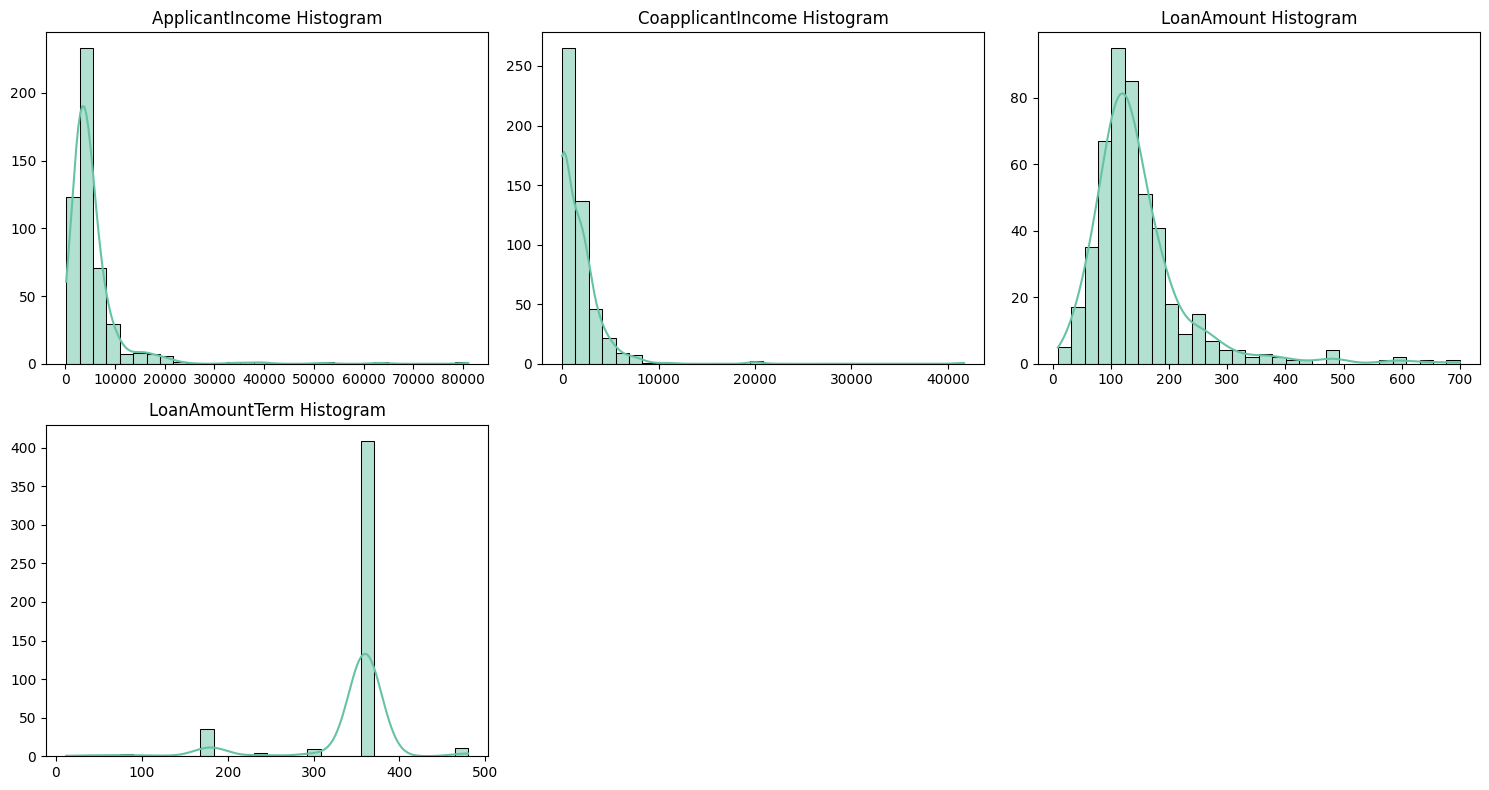

In [25]:
# NUMERICAL VARIABLES(FEATURES) DISTRIBUTION
plot_numerical_distributions(train_df, NUM_FEATURES)

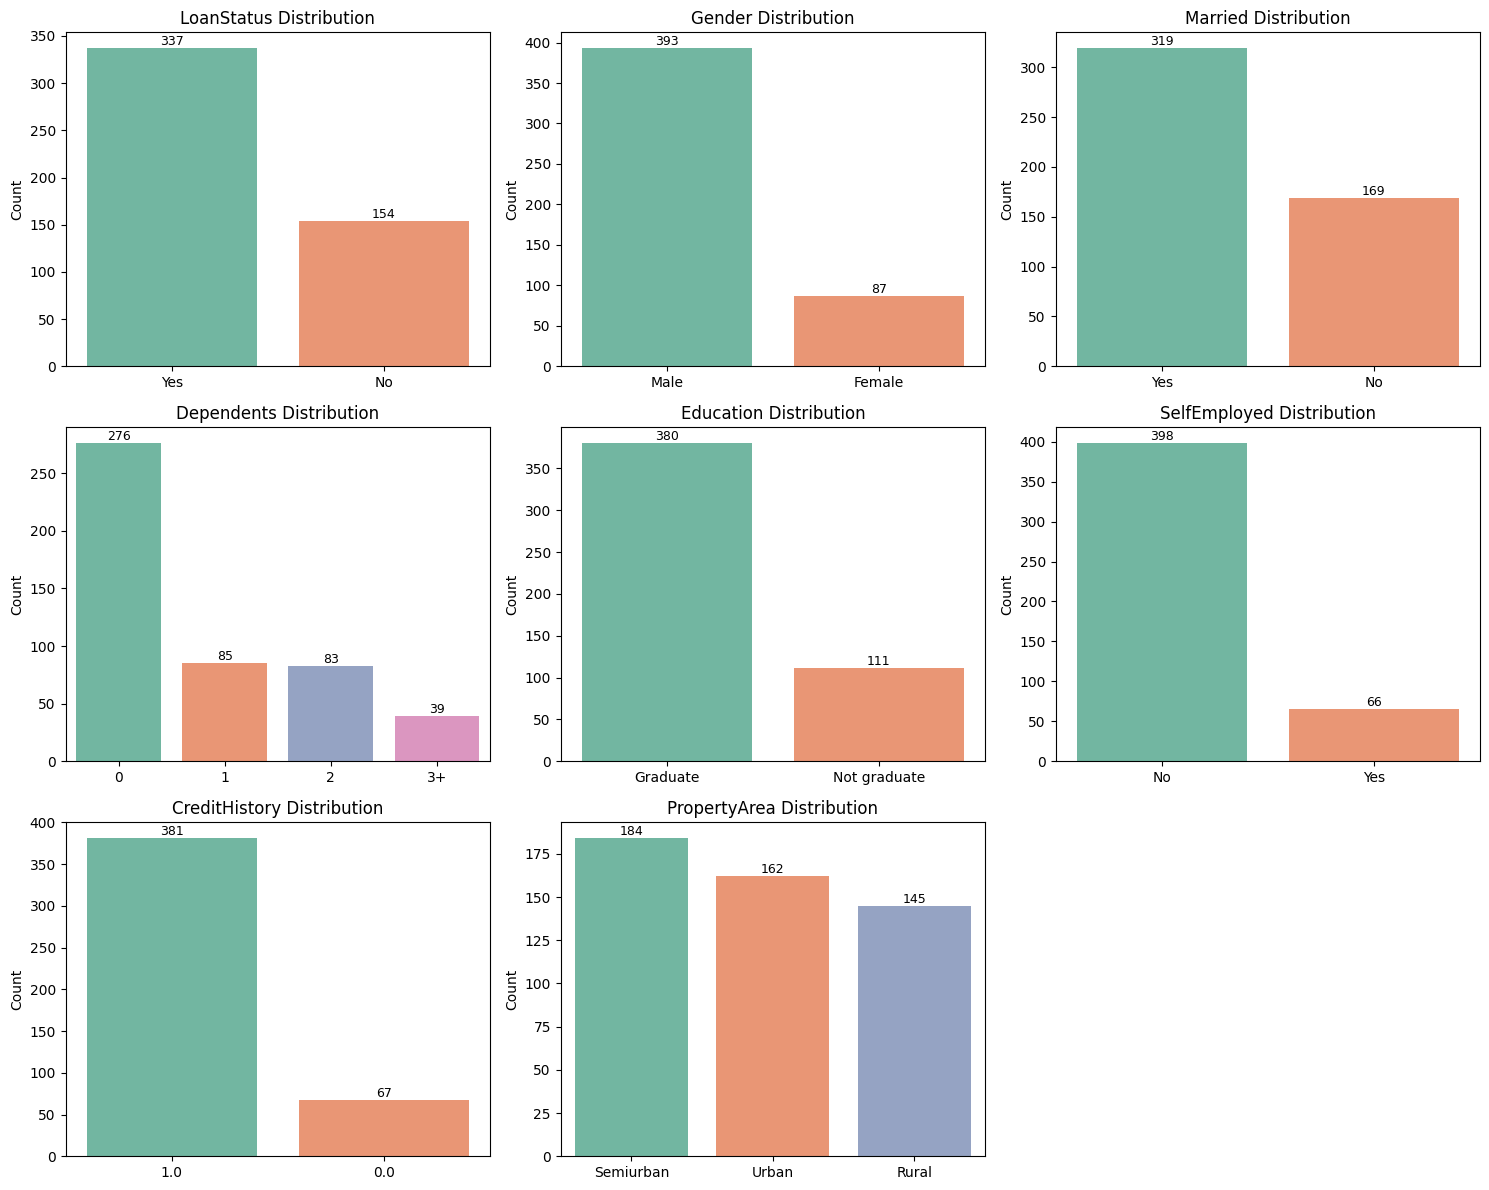

In [26]:
# CATEGORICAL DISTRIBUTIONS
plot_categorical_distributions(df=train_df, categorical_columns=[LABEL] + CAT_FEATURES)

### Bivariate analysis

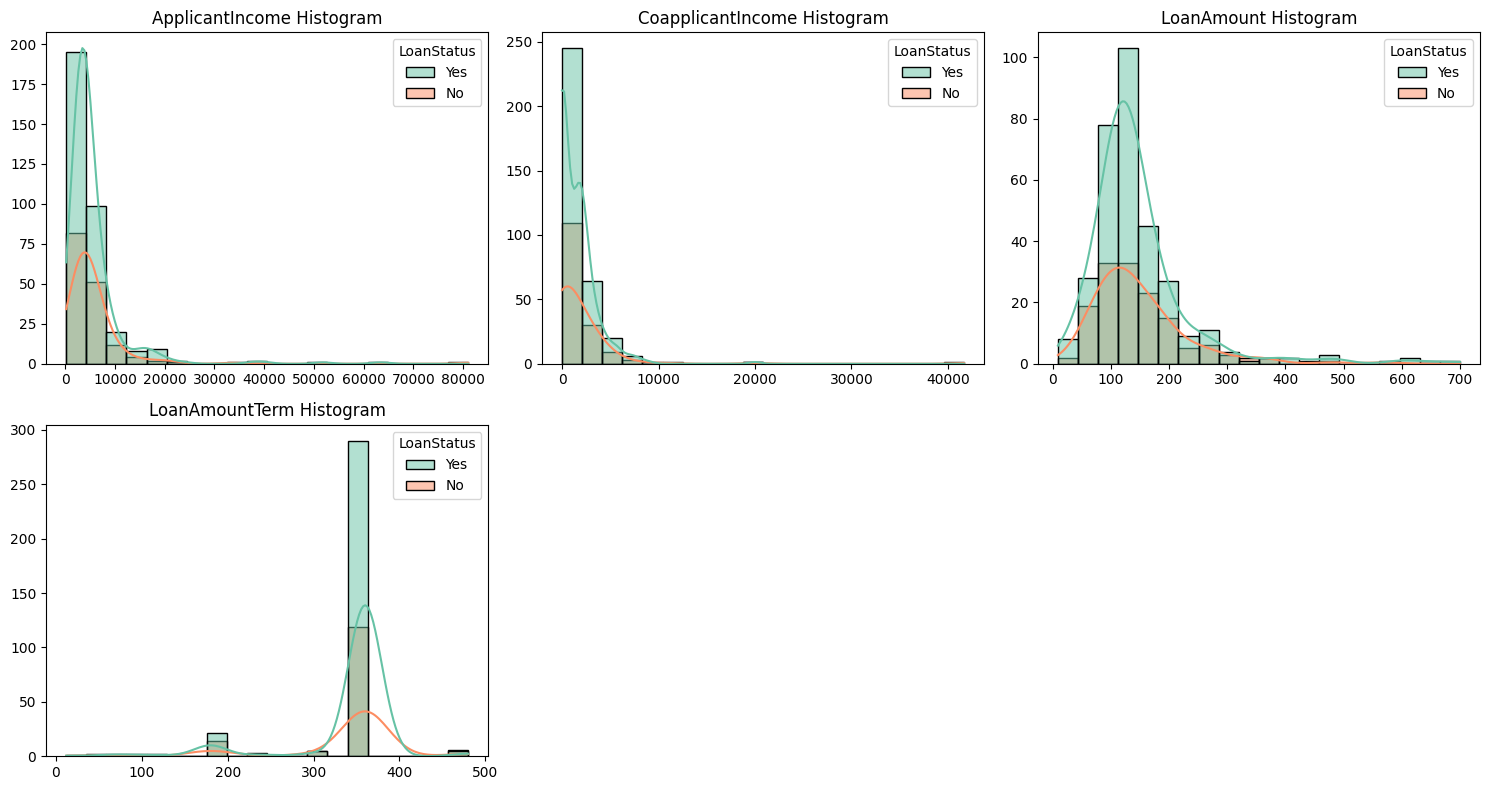

In [27]:
# NUMERICAL FEATURES VS TARGET(CATEGORICAL) DISTRIBUTION
plot_numerical_distributions(train_df, NUM_FEATURES, target_column=LABEL, bins=20)

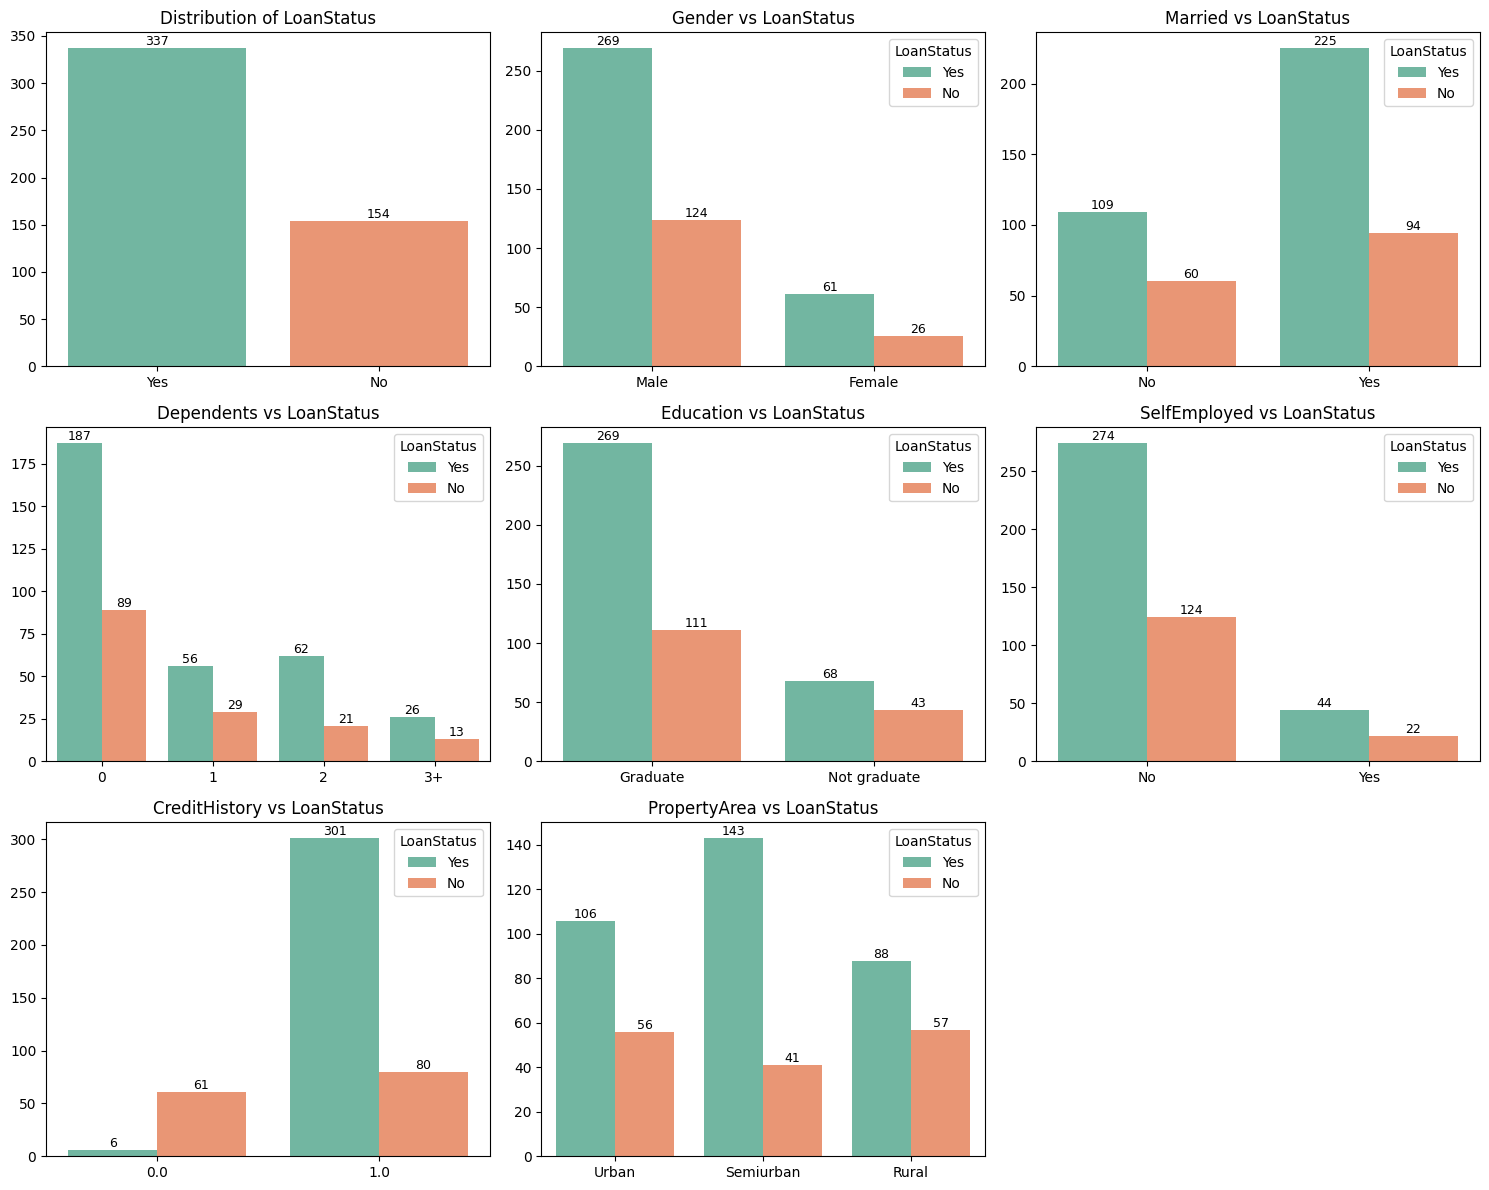

In [28]:
# CATEGORICAL TARGET VS CATEGORICAL FEATURES DISTRIBUTIONS
plot_target_vs_categorical_features(train_df, categorical_columns=CAT_FEATURES, target_column="LoanStatus", xtick_rotation=0, plot_types="bar")

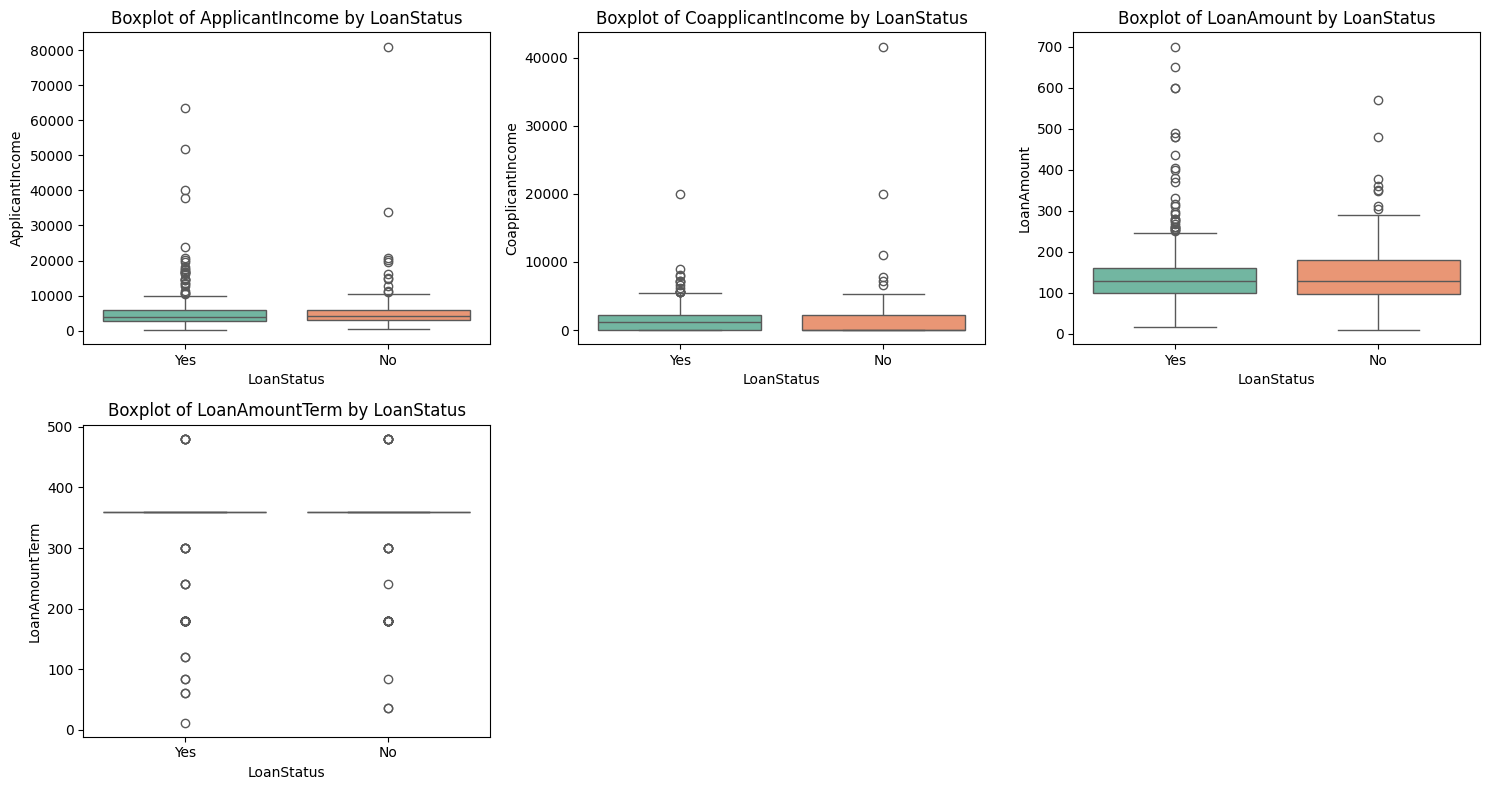

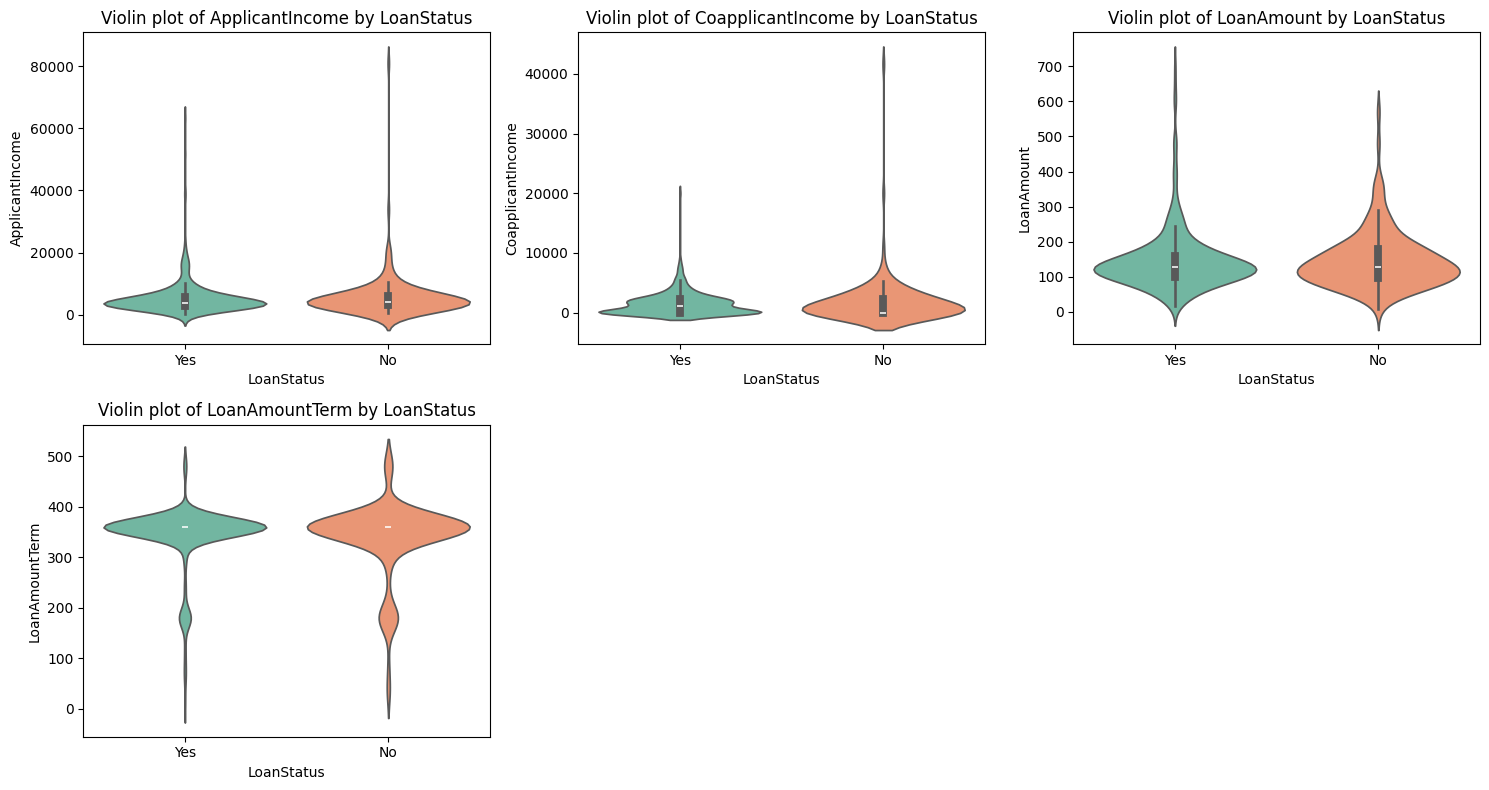

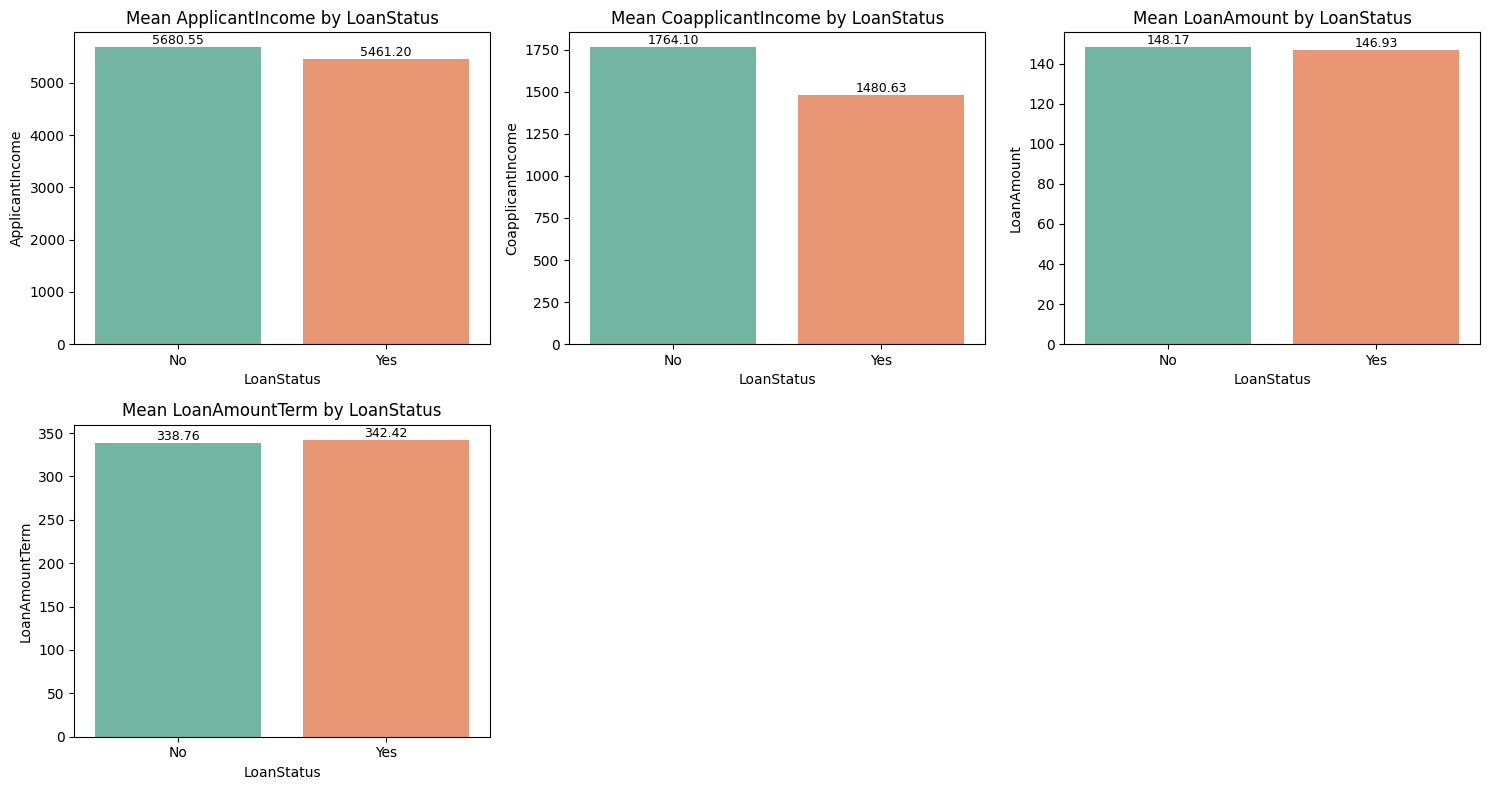

In [29]:
# CATEGORICAL TARGET VS NUMERICAL FEATURES
eda_categorical_vs_numerical(train_df, numerical_columns=NUM_FEATURES, label_column="LoanStatus")

## Modeling

Preprocessing
- Handle missing data
    - Drop all missing value, then ensure all variables are passed when predicting (this is particulary important in production when deploying using API endpoint)
    - Statistical imputation
        - Numerical statistics: mean or median or constant, use appropriately for each feature
        - Categorical statistics: most_frequent or constant, use appropriately for each feature
- Build preprocessing pipeline

In [30]:
# copy data for test both options
train_data_with_missing_values = train_df.copy()
test_data_with_missing_values = test_df.copy()

### Dropping missing values

In [31]:
# drop missing values
train_df = train_df.dropna()
test_df = test_df.dropna()

Build pipeline

In [32]:

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import ColumnTransformer

# we can still add an imputer even though we have dropped the missing values (this only reduces the training samples)
# while adding imputer prevents chaos when making prediction with the model, especially in api deployment
num_pipeline = Pipeline(steps=[("num_imputer", sklearn.impute.SimpleImputer(strategy="mean")), ("scaler", StandardScaler())])
cat_pipeline = Pipeline(steps=[("cat_imputer", sklearn.impute.SimpleImputer(strategy="most_frequent")), ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])


In [33]:
# ensure numerical pipeline works
transformed_num = num_pipeline.fit_transform(train_df[NUM_FEATURES])
print("Shape:", transformed_num.shape)
print("Column Means:", transformed_num.mean(axis=0))
print("Column Deviations:", transformed_num.std(axis=0))

Shape: (381, 4)
Column Means: [4.66235391e-17 9.32470782e-17 1.28214733e-16 6.29417778e-17]
Column Deviations: [1. 1. 1. 1.]


In [34]:
# ensure categorical pipeline works
transformed_cat = cat_pipeline.fit_transform(train_df[CAT_FEATURES])
print("Shape:", transformed_cat.shape)
print(transformed_cat)

Shape: (381, 17)
[[0. 1. 1. ... 0. 0. 1.]
 [0. 1. 0. ... 0. 1. 0.]
 [0. 1. 0. ... 1. 0. 0.]
 ...
 [0. 1. 0. ... 0. 1. 0.]
 [1. 0. 0. ... 0. 1. 0.]
 [1. 0. 0. ... 0. 1. 0.]]


In [35]:
# creating a transformer to combine the two pipelines
preprocessor = ColumnTransformer([
    ("num_preprocessor", num_pipeline, NUM_FEATURES),
    ("cat_preprocessor", cat_pipeline, CAT_FEATURES)
])

Xtrain = preprocessor.fit_transform(train_df[NUM_FEATURES + CAT_FEATURES])
Xtest = preprocessor.transform(test_df[NUM_FEATURES + CAT_FEATURES])
Xtrain.shape, Xtest.shape

((381, 21), (99, 21))

Build model pipeline, fit and evaluate

In [36]:
# create the full pipeline for the model
from sklearn.linear_model import LogisticRegression

loan_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression())
])

FEATURES = NUM_FEATURES + CAT_FEATURES
train_features = train_df[FEATURES]
train_labels = train_df["LoanStatus"]

test_features = test_df[FEATURES]
test_labels = test_df["LoanStatus"]

loan_pipe.fit(train_features, train_labels)
loan_pipe.score(test_features, test_labels)

0.8484848484848485

In [37]:
from sklearn import metrics

# classification report
test_pred = loan_pipe.predict(test_features)

report = metrics.classification_report(test_labels, test_pred)
print(report)

              precision    recall  f1-score   support

          No       0.94      0.53      0.68        30
         Yes       0.83      0.99      0.90        69

    accuracy                           0.85        99
   macro avg       0.89      0.76      0.79        99
weighted avg       0.86      0.85      0.83        99



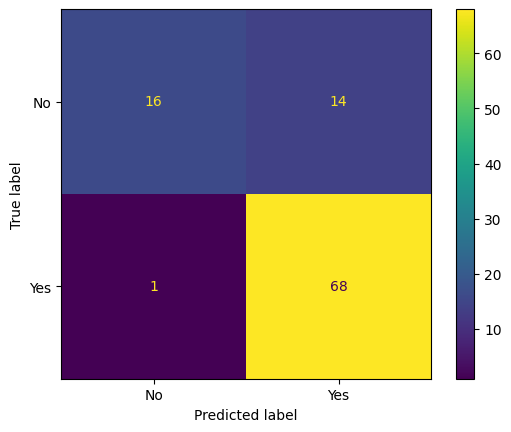

In [38]:
# confusion matrix
labels = np.unique(test_labels).tolist()
cm = metrics.confusion_matrix(test_labels, test_pred)
cm_plot = metrics.ConfusionMatrixDisplay(cm, display_labels=labels)
cm_plot.plot()
plt.show()

In [39]:
def build_pipeline(
    num_features,
    cat_features,
    model=None,
    num_impute_strategy="mean",
    cat_impute_strategy="most_frequent",
    scale_numeric=True,
    encoder_handle_unknown="ignore",
    encoder_sparse=False
):
    """
    Build a preprocessing + model pipeline

    Parameters:
    - num_features (list): numerical feature names
    - cat_features (list): categorical feature names
    - model: sklearn model (default = LogisticRegression)
    - num_impute_strategy (str)
    - cat_impute_strategy (str)
    - scale_numeric (bool)
    - encoder_handle_unknown (str)
    - encoder_sparse (bool)

    Returns:
    - pipeline (Pipeline)
    """
    from sklearn.pipeline import Pipeline
    from sklearn.compose import ColumnTransformer
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    from sklearn.linear_model import LogisticRegression

    # -------------------------
    # Numerical Pipeline
    # -------------------------
    num_steps = [
        ("num_imputer", SimpleImputer(strategy=num_impute_strategy))
    ]

    if scale_numeric:
        num_steps.append(("scaler", StandardScaler()))

    num_pipeline = Pipeline(steps=num_steps)

    # -------------------------
    # Categorical Pipeline
    # -------------------------
    cat_pipeline = Pipeline(steps=[
        ("cat_imputer", SimpleImputer(strategy=cat_impute_strategy)),
        ("encoder", OneHotEncoder(
            handle_unknown=encoder_handle_unknown,
            sparse_output=encoder_sparse
        ))
    ])

    # -------------------------
    # Column Transformer
    # -------------------------
    preprocessor = ColumnTransformer([
        ("num", num_pipeline, num_features),
        ("cat", cat_pipeline, cat_features)
    ])

    # -------------------------
    # Default Model
    # -------------------------
    if model is None:
        model = LogisticRegression(max_iter=1000)

    # -------------------------
    # Full Pipeline
    # -------------------------
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    return pipeline


### Imputing missing values in training

In [40]:
train_data_with_missing_values.head()

,Gender,Married,Dependents,Education,SelfEmployed,ApplicantIncome,CoapplicantIncome,LoanAmount,LoanAmountTerm,CreditHistory,PropertyArea,LoanStatus
154,Male,No,0,Graduate,No,3254,0.0,50.0,360.0,1.0,Urban,Yes
239,Male,Yes,1,Graduate,No,3315,0.0,96.0,360.0,1.0,Semiurban,Yes
448,Male,Yes,2,Graduate,No,3340,1710.0,150.0,360.0,0.0,Rural,No
471,Male,Yes,1,Not graduate,No,2653,1500.0,113.0,180.0,0.0,Rural,No
273,Male,Yes,0,Graduate,No,2620,2223.0,150.0,360.0,1.0,Semiurban,Yes


In [41]:
train_data_with_missing_values.isnull().sum()

Gender               11
Married               3
Dependents            8
Education             0
SelfEmployed         27
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           20
LoanAmountTerm       12
CreditHistory        43
PropertyArea          0
LoanStatus            0
dtype: int64

In [42]:
# fetch training data
train_features = train_data_with_missing_values[FEATURES]
train_labels = train_data_with_missing_values["LoanStatus"]

# fetch test data
test_features =test_data_with_missing_values[FEATURES]
test_labels = test_data_with_missing_values["LoanStatus"]


Build pipeline, fit and evaluate

In [43]:
classifier = build_pipeline(NUM_FEATURES, CAT_FEATURES, model=LogisticRegression())
classifier.fit(train_features, train_labels)
classifier.score(test_features, test_labels)

0.8617886178861789

In [44]:
from sklearn import metrics

# classification report
test_pred = classifier.predict(test_features)

# metrics
report = metrics.classification_report(test_labels, test_pred)
accuracy = metrics.accuracy_score(test_labels, test_pred)
recall = metrics.recall_score(test_labels, test_pred, average="binary", pos_label="Yes")
precision = metrics.precision_score(test_labels, test_pred, average="binary", pos_label="Yes")
f1_score = metrics.f1_score(test_labels, test_pred, average="weighted")

print(report, end="\n\n")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1_score:", f1_score)

              precision    recall  f1-score   support

          No       0.96      0.58      0.72        38
         Yes       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123


Accuracy: 0.8617886178861789
Precision: 0.84
Recall: 0.9882352941176471
F1_score: 0.850398579307016


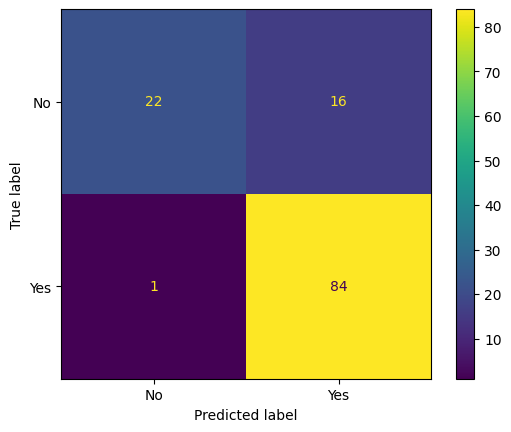

In [45]:
# confusion matrix
labels = np.unique(test_labels).tolist()
cm = metrics.confusion_matrix(test_labels, test_pred)
cm_plot = metrics.ConfusionMatrixDisplay(cm, display_labels=labels)
cm_plot.plot()
plt.show()

### Serialize model

In [46]:
import joblib
model_path = "models/classifier.joblib"
os.makedirs(os.path.dirname(model_path), exist_ok=True)
joblib.dump(classifier, model_path)


['models/classifier.joblib']

## Production Features

In [47]:
train_features.columns.tolist()

['ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'LoanAmountTerm',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'SelfEmployed',
 'CreditHistory',
 'PropertyArea']

## Save test data

In [48]:
test_features.to_csv("data/test_features.csv", index=False)
test_labels.to_csv("data/test_labels.csv", index=False)

In [49]:
test_features.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,LoanAmountTerm,Gender,Married,Dependents,Education,SelfEmployed,CreditHistory,PropertyArea
150,6277,0.0,118.0,360.0,Male,No,0,Graduate,No,0.0,Rural
559,4180,2306.0,182.0,360.0,Female,Yes,0,Graduate,No,1.0,Semiurban
598,9963,0.0,180.0,360.0,Male,Yes,0,Graduate,Yes,1.0,Rural
235,5500,1260.0,170.0,360.0,Male,Yes,1,Graduate,No,1.0,Rural
145,2330,4486.0,100.0,360.0,Female,Yes,0,Graduate,No,1.0,Semiurban


In [50]:
test_features.dtypes

ApplicantIncome         int64
CoapplicantIncome     float64
LoanAmount            float64
LoanAmountTerm        float64
Gender                 object
Married                object
Dependents             object
Education              object
SelfEmployed           object
CreditHistory        category
PropertyArea           object
dtype: object

In [51]:
test_pred

array(['No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes',
       'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'No', 'Yes', 'No', 'No',
       'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No',
       'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'Yes',
       'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes',
       'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'No',
       'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes',
       'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'Yes',
       'Yes', 'Yes', 'Yes', 'Yes', 'No', 'No', 'Yes', 'Yes', 'Yes', 'Yes',
       'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'No', 'Yes', 'Yes',
       'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes',
       'Yes', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes',
       'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'No', 'Yes', 'No'],
      dtype=object)